In [1]:
import numpy as np
import matplotlib.pyplot as plt
from simple_pe.param_est import metric
from simple_pe.param_est.pe import SimplePESamples
from simple_pe.waveforms import waveform, parameter_bounds

/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this p

lal.MSUN_SI != Msun


In [2]:
def protect_metric_corner(x, dx_directions,
                          params=['chi_align', 'symmetric_mass_ratio',
                                  'ecc10sqrd'],
                          mins=None, maxs=None, deccsqrd=0.01,
                          dchi=0.1, deta=0.01):
    """
    Check if the input point is in the corner of parameter space

    :param x: dictionary with parameter values for initial point
    :param dx_directions: list of parameters for which to calculate waveform
                          variations
    :param params: list of parameters to check for corner of parameter space
    :param mins: minimum values of parameters
    :param maxs: maximum values of parameters
    :param deccsqrd: minimum distance from parameter bound for ecc10sqrd
    :param dchi: minimum distance from parameter bound for chi_align
    :param deta: minimum distance from parameter bound for
    symmetric_mass_ratio
    :return x: dictionary with parameter values for initial point, shifted
               if necessary
    :return total_diff: dictionary with the amount of shift for each parameter
    """

    if mins is None:
        mins = parameter_bounds.param_mins
    if maxs is None:
        maxs = parameter_bounds.param_maxs

    # Find railing parameters
    corner_params = {}
    diff_params = {}
    if 'symmetric_mass_ratio' in params:
        if 'symmetric_mass_ratio' in dx_directions:
            max_eta = maxs['symmetric_mass_ratio']
            if x['symmetric_mass_ratio'][0] > max_eta - deta:
                corner_params['symmetric_mass_ratio'] = max_eta - deta
                diff = (corner_params['symmetric_mass_ratio'] -
                        x['symmetric_mass_ratio'][0])
                diff_params['symmetric_mass_ratio'] = diff
    if 'chi_align' in params:
        if 'chi_align' in dx_directions:
            min_chi = mins['chi_align']
            if x['chi_align'][0] < min_chi + dchi:
                corner_params['chi_align'] = min_chi + dchi
                diff = (corner_params['chi_align'] - x['chi_align'][0])
                diff_params['chi_align'] = diff
            max_chi = maxs['chi_align']
            if x['chi_align'][0] > max_chi - dchi:
                corner_params['chi_align'] = max_chi - dchi
                diff = (corner_params['chi_align'] - x['chi_align'][0])
                diff_params['chi_align'] = diff
    if 'ecc10sqrd' in params:
        if 'ecc10sqrd' in dx_directions:
            min_eccsqrd = mins['ecc10sqrd']
            if x['ecc10sqrd'][0] < min_eccsqrd + deccsqrd:
                corner_params['ecc10sqrd'] = min_eccsqrd + deccsqrd
                diff = (corner_params['ecc10sqrd'] - x['ecc10sqrd'][0])
                diff_params['ecc10sqrd'] = diff

    # Fix railing if required
    total_diff = {}
    if len(corner_params) > 1:
        ordered_params = []
        for param in params:
            if param in corner_params.keys():
                ordered_params.append(param)
        for param in ordered_params[:-1]:
            print(f'Calculating metric at {param} of {corner_params[param]} '
                  f'instead of {x[param][0]}to avoid corner of '
                  'parameter space')
            x[param] = np.array([corner_params[param]])
            total_diff[param] = diff_params[param]

    return x, total_diff


def find_metric_and_eigendirections(
    x, dx_directions, snr, f_low, psd, approximant="IMRPhenomD",
    mins=None, maxs=None, tolerance=0.05, max_iter=20,
    ncpus=1, mute_multiprocessing=True,
    n_ecc_gen=6, avoid_ecc_corner=True, mismatch=None
):
    """
    Calculate the eigendirections in parameter space, normalized to enclose a
    90% confidence region at the requested SNR

    :param x: dictionary with parameter values for initial point
    :param dx_directions: list of parameters for which to calculate waveform
    variations
    :param snr: the observed SNR
    :param f_low: low frequency cutoff
    :param psd: the power spectrum to use in calculating the match
    :param approximant: the approximant to use
    :param tolerance: the allowed error in the metric is (tolerance * mismatch)
    :param max_iter: the maximum number of iterations
    :param ncpus: number of cpus to use to calculate metric
    :param mute_multiprocessing: whether to mute the output of the
                                 multiprocessing threads
    :param n_ecc_gen: number of component waveforms to generate eccentric
                      harmonics
    :param avoid_ecc_corner: whether to avoid the eccentricity-eta corner of
                             parameter space when calculating the metric
    :param mismatch: mismatch to build metric at, overrides snr parameter
                     if provided
    :return g: the mismatch metric in physical space
    """

    # Check if in corner of eccentric parameter space, and shift if so
    x_tmp = SimplePESamples(x.copy())
    if avoid_ecc_corner:
        x_tmp, param_diff = protect_metric_corner(x_tmp, dx_directions,
                                                  mins=mins, maxs=maxs)

    # mismatch overrides snr parameter if provided
    if mismatch:
        snr = None
    else:
        mismatch = 0

    # initial directions and initial spacing
    g = metric.Metric(x_tmp, dx_directions, mismatch, f_low, psd, approximant,
               tolerance, prob=0.9, snr=snr, ncpus=ncpus,
               mute_multiprocessing=mute_multiprocessing, mins=None, maxs=None,
               n_ecc_gen=n_ecc_gen)
    g.iteratively_update_metric(max_iter)

    # Shift back if required
    if avoid_ecc_corner and len(param_diff.keys()) > 0:
        alpha = waveform.check_physical(g.x, param_diff, -1)
        g.x = waveform.offset_params(g.x, param_diff, -alpha)

    return g


In [3]:
from simple_pe import io
f_low = 20
asd_data = {'H1': '/home/ben.patterson/projects/simple-pe/examples/zero-noise/aligo_O4high.txt',
            'L1': '/home/ben.patterson/projects/simple-pe/examples/zero-noise/aligo_O4high.txt',
            'V1': '/home/ben.patterson/projects/simple-pe/examples/zero-noise/avirgo_O4high_NEW.txt'}
psds = io.load_psd_from_file(
           {}, asd_data, 1/32, f_low, 2048,
       )
hm_psd = io.calculate_harmonic_mean_psd(psds)

/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)


Calculating the metric | iteration 2 < 2| error 6.5e-12 > 1.6e-11: 


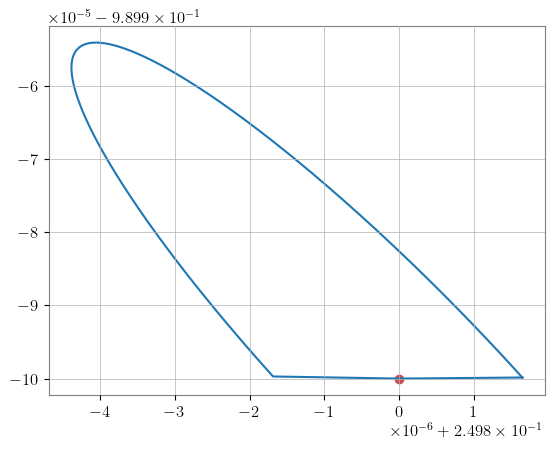

In [17]:
snr = 10**5

x = {'chirp_mass': 24, 'symmetric_mass_ratio': 0.2498, 'chi_align': -0.99}
dx_directions = x.keys()

g = find_metric_and_eigendirections(
    x, dx_directions, snr, f_low, hm_psd, approximant="IMRPhenomXPHM",
    mins=None, maxs=None, tolerance=0.05, max_iter=2,
    ncpus=1, mute_multiprocessing=True,
    n_ecc_gen=6, avoid_ecc_corner=False, mismatch=None
)

g.project_metric(['symmetric_mass_ratio', 'chi_align'])
pts = g.generate_ellipse(npts=10**3, projected=True)
plt.plot(pts['symmetric_mass_ratio'], pts['chi_align'])
plt.scatter(x['symmetric_mass_ratio'], x['chi_align'], c='r')

Calculating the metric | iteration 2 < 2| error 8.6e-12 > 1.6e-11: 


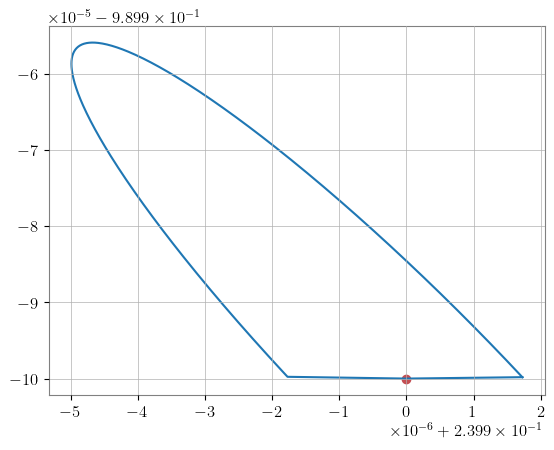

In [18]:
snr = 10**5

x = {'chirp_mass': 24, 'symmetric_mass_ratio': 0.2399, 'chi_align': -0.99}
dx_directions = x.keys()

g = find_metric_and_eigendirections(
    x, dx_directions, snr, f_low, hm_psd, approximant="IMRPhenomXPHM",
    mins=None, maxs=None, tolerance=0.05, max_iter=2,
    ncpus=1, mute_multiprocessing=True,
    n_ecc_gen=6, avoid_ecc_corner=False, mismatch=None
)

g.project_metric(['symmetric_mass_ratio', 'chi_align'])
pts = g.generate_ellipse(npts=10**3, projected=True)
plt.plot(pts['symmetric_mass_ratio'], pts['chi_align'])
plt.scatter(x['symmetric_mass_ratio'], x['chi_align'], c='r')

Calculating the metric | iteration 2 < 2| error 1.1e-11 > 1.6e-11: 


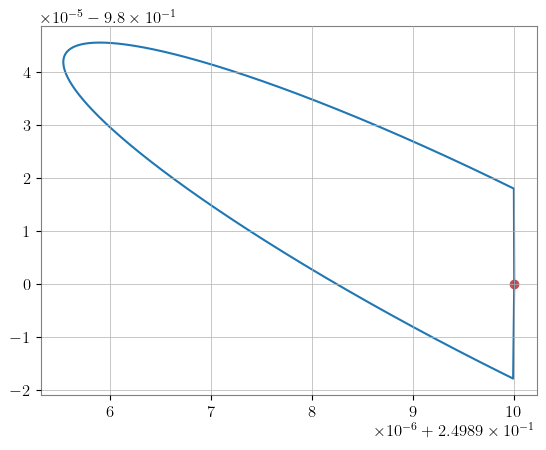

In [19]:
snr = 10**5

x = {'chirp_mass': 24, 'symmetric_mass_ratio': 0.2499, 'chi_align': -0.98}
dx_directions = x.keys()

g = find_metric_and_eigendirections(
    x, dx_directions, snr, f_low, hm_psd, approximant="IMRPhenomXPHM",
    mins=None, maxs=None, tolerance=0.05, max_iter=2,
    ncpus=1, mute_multiprocessing=True,
    n_ecc_gen=6, avoid_ecc_corner=False, mismatch=None
)

g.project_metric(['symmetric_mass_ratio', 'chi_align'])
pts = g.generate_ellipse(npts=10**3, projected=True)
plt.plot(pts['symmetric_mass_ratio'], pts['chi_align'])
plt.scatter(x['symmetric_mass_ratio'], x['chi_align'], c='r')

2026-07-14  15:18:11 PESummary WARNING : Could not find f_final in input file and one was not passed from the command line. Using 1024.0Hz as default
2026-07-14  15:18:11 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default
Calculating the metric | iteration 2 < 2| error 5e-12 > 1.6e-11: 


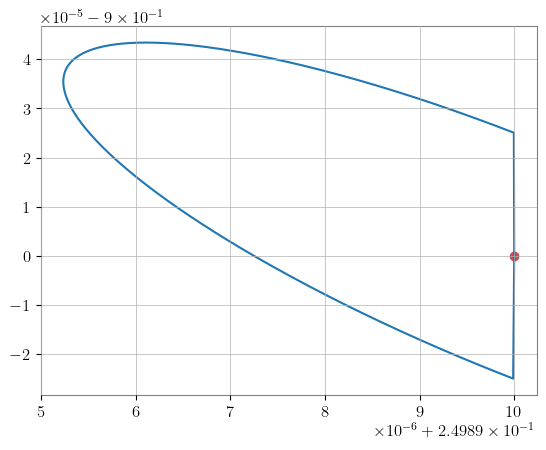

In [4]:
snr = 10**5

x = {'chirp_mass': 24, 'symmetric_mass_ratio': 0.2499, 'chi_align': -0.9}
dx_directions = x.keys()

g = find_metric_and_eigendirections(
    x, dx_directions, snr, f_low, hm_psd, approximant="IMRPhenomXPHM",
    mins=None, maxs=None, tolerance=0.05, max_iter=2,
    ncpus=1, mute_multiprocessing=True,
    n_ecc_gen=6, avoid_ecc_corner=False, mismatch=None
)

g.project_metric(['symmetric_mass_ratio', 'chi_align'])
pts = g.generate_ellipse(npts=10**3, projected=True)
plt.plot(pts['symmetric_mass_ratio'], pts['chi_align'])
plt.scatter(x['symmetric_mass_ratio'], x['chi_align'], c='r')

Calculating the metric | iteration 2 < 2| error 6.6e-12 > 1.6e-11: 


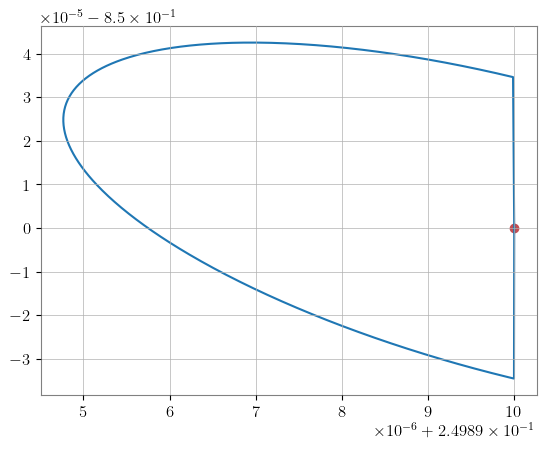

In [5]:
snr = 10**5

x = {'chirp_mass': 24, 'symmetric_mass_ratio': 0.2499, 'chi_align': -0.85}
dx_directions = x.keys()

g = find_metric_and_eigendirections(
    x, dx_directions, snr, f_low, hm_psd, approximant="IMRPhenomXPHM",
    mins=None, maxs=None, tolerance=0.05, max_iter=2,
    ncpus=1, mute_multiprocessing=True,
    n_ecc_gen=6, avoid_ecc_corner=False, mismatch=None
)

g.project_metric(['symmetric_mass_ratio', 'chi_align'])
pts = g.generate_ellipse(npts=10**3, projected=True)
plt.plot(pts['symmetric_mass_ratio'], pts['chi_align'])
plt.scatter(x['symmetric_mass_ratio'], x['chi_align'], c='r')

Calculating the metric | iteration 2 < 2| error 5e-12 > 1.6e-11:   


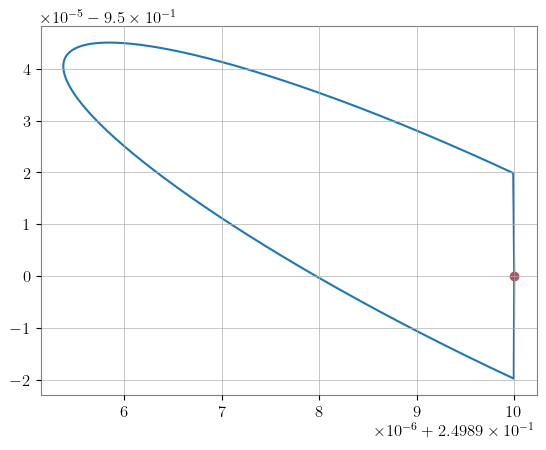

In [6]:
snr = 10**5

x = {'chirp_mass': 24, 'symmetric_mass_ratio': 0.2499, 'chi_align': -0.95}
dx_directions = x.keys()

g = find_metric_and_eigendirections(
    x, dx_directions, snr, f_low, hm_psd, approximant="IMRPhenomXPHM",
    mins=None, maxs=None, tolerance=0.05, max_iter=2,
    ncpus=1, mute_multiprocessing=True,
    n_ecc_gen=6, avoid_ecc_corner=False, mismatch=None
)

g.project_metric(['symmetric_mass_ratio', 'chi_align'])
pts = g.generate_ellipse(npts=10**3, projected=True)
plt.plot(pts['symmetric_mass_ratio'], pts['chi_align'])
plt.scatter(x['symmetric_mass_ratio'], x['chi_align'], c='r')

Failed to achieve requested tolerance.  Requested: 0.0016achieved 0.008: 


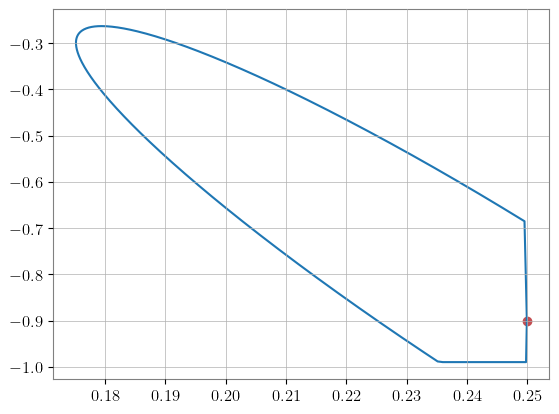

In [7]:
snr = 10

x = {'chirp_mass': 24, 'symmetric_mass_ratio': 0.2499, 'chi_align': -0.9}
dx_directions = x.keys()

g = find_metric_and_eigendirections(
    x, dx_directions, snr, f_low, hm_psd, approximant="IMRPhenomXPHM",
    mins=None, maxs=None, tolerance=0.05, max_iter=2,
    ncpus=1, mute_multiprocessing=True,
    n_ecc_gen=6, avoid_ecc_corner=False, mismatch=None
)

g.project_metric(['symmetric_mass_ratio', 'chi_align'])
pts = g.generate_ellipse(npts=10**3, projected=True)
plt.plot(pts['symmetric_mass_ratio'], pts['chi_align'])
plt.scatter(x['symmetric_mass_ratio'], x['chi_align'], c='r')

Failed to achieve requested tolerance.  Requested: 0.0016achieved 0.013: 


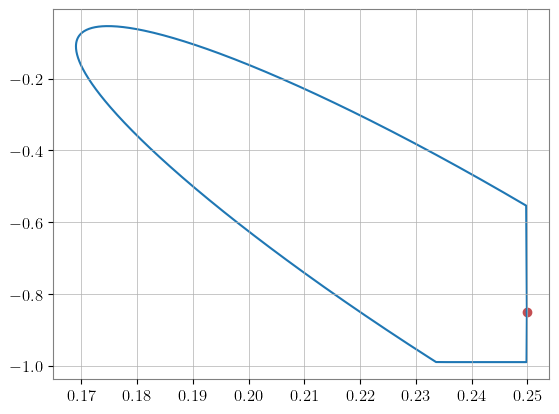

In [8]:
snr = 10

x = {'chirp_mass': 24, 'symmetric_mass_ratio': 0.2499, 'chi_align': -0.85}
dx_directions = x.keys()

g = find_metric_and_eigendirections(
    x, dx_directions, snr, f_low, hm_psd, approximant="IMRPhenomXPHM",
    mins=None, maxs=None, tolerance=0.05, max_iter=2,
    ncpus=1, mute_multiprocessing=True,
    n_ecc_gen=6, avoid_ecc_corner=False, mismatch=None
)

g.project_metric(['symmetric_mass_ratio', 'chi_align'])
pts = g.generate_ellipse(npts=10**3, projected=True)
plt.plot(pts['symmetric_mass_ratio'], pts['chi_align'])
plt.scatter(x['symmetric_mass_ratio'], x['chi_align'], c='r')

Failed to achieve requested tolerance.  Requested: 0.0016achieved 0.0049: 


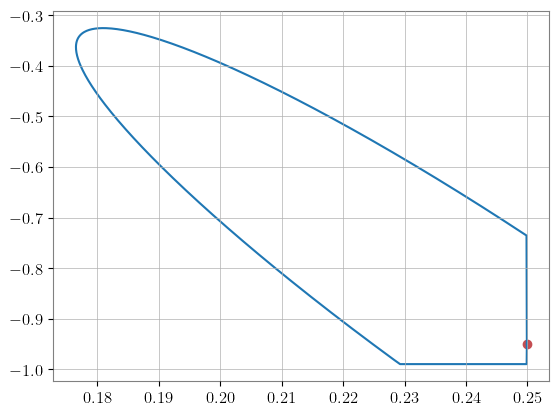

In [9]:
snr = 10

x = {'chirp_mass': 24, 'symmetric_mass_ratio': 0.2499, 'chi_align': -0.95}
dx_directions = x.keys()

g = find_metric_and_eigendirections(
    x, dx_directions, snr, f_low, hm_psd, approximant="IMRPhenomXPHM",
    mins=None, maxs=None, tolerance=0.05, max_iter=2,
    ncpus=1, mute_multiprocessing=True,
    n_ecc_gen=6, avoid_ecc_corner=False, mismatch=None
)

g.project_metric(['symmetric_mass_ratio', 'chi_align'])
pts = g.generate_ellipse(npts=10**3, projected=True)
plt.plot(pts['symmetric_mass_ratio'], pts['chi_align'])
plt.scatter(x['symmetric_mass_ratio'], x['chi_align'], c='r')